In [1]:
# General notebook settings
import logging
import warnings

import pypsa

warnings.filterwarnings("error", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="The locs attribute was deprecated")
logging.getLogger("gurobipy").propagate = False
pypsa.options.params.optimize.log_to_console = False

# Flow-based market coupling

Flow-based market coupling (FBMC) is the capacity-allocation mechanism of the European
day-ahead market in the Core region. Instead of fixed exchange limits between bidding zones,
the market is bounded by a *flow-based domain*: a set of linear inequalities that link the
zones' net positions to the loading of the critical network elements of the meshed grid.

PyPSA represents this with the `FlowBasedConstraint` component. Each entity is one **critical
network element and contingency (CNEC)** and carries one inequality

$$\sum_z \text{zonal\_ptdf}_{c,z}\, NP_z \le \text{RAM}_c ,$$

where

- $NP_z$ is the **net position** of zone $z$ (its net export, `generation - load`),
- $\text{zonal\_ptdf}_{c,z}$ is the **zonal PTDF**: how strongly a unit net export of zone
  $z$ loads element $c$, and
- $\text{RAM}_c$ is the **remaining available margin**: the headroom left on element $c$ for
  market exchanges.

This example builds a small domain from scratch, clears it, reads off the FBMC indicators
(net positions, zonal prices, binding CNECs and their shadow prices), and finally couples the
zones to external neighbours through *advanced hybrid coupling* (AHC) and *evolved flow-based
coupling* (EvFB). Throughout we take the domain (PTDF and RAM) as **given input** — computing
it from a nodal grid model is a separate step.

The component and its importers are documented in the
[user guide](../user-guide/components/flow-based-constraints.md).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## A three-zone domain

Consider three zones **A**, **B** and **C** whose physical grid is a symmetric triangle of
three lines with equal reactance. With zone C as the reference, the zonal PTDF of each line
follows from the power-flow equations; monitoring every line in both directions gives six
CNECs (`AB+`, `AB-`, ...). We take the resulting PTDF and a remaining margin per CNEC as
given, and collect them in a `cnec x zone` DataFrame plus a `ram` series.

In [3]:
zones = ["A", "B", "C"]

# equal-reactance triangle, C as reference; each line monitored in both directions
ptdf_line = pd.DataFrame(
    {
        "AB": {"A": 1 / 3, "B": -1 / 3, "C": 0.0},
        "BC": {"A": 1 / 3, "B": 2 / 3, "C": 0.0},
        "AC": {"A": 2 / 3, "B": 1 / 3, "C": 0.0},
    }
).T
zonal_ptdf = pd.concat(
    [ptdf_line.rename(lambda s: f"{s}+"), (-ptdf_line).rename(lambda s: f"{s}-")]
).sort_index()
zonal_ptdf.index.name = "cnec"

ram = pd.Series(
    {"AB+": 1000.0, "AB-": 1000.0, "BC+": 1500.0, "BC-": 1500.0, "AC+": 2000.0, "AC-": 2000.0}
)
zonal_ptdf

,A,B,C
cnec,,,
AB+,0.333333,-0.333333,0.0
AB-,-0.333333,0.333333,-0.0
AC+,0.666667,0.333333,0.0
AC-,-0.666667,-0.333333,-0.0
BC+,0.333333,0.666667,0.0
BC-,-0.333333,-0.666667,-0.0


Now the market: one bus per zone with a generator and a load. Zone A is cheap, B is
expensive, C is in between. There are **no lines between the zones** — the flow-based domain
*replaces* the inter-zonal grid. The domain is attached as a single `FlowBasedConstraint`
component, passing the PTDF matrix through the `zonal_ptdf` argument.

In [4]:
load = pd.Series({"A": 500.0, "B": 1500.0, "C": 1000.0})
cost = pd.Series({"A": 10.0, "B": 80.0, "C": 50.0})

n = pypsa.Network()
n.set_snapshots([0])
n.add("Bus", zones)
n.add("Load", "load_" + pd.Index(zones), bus=zones, p_set=load.values)
n.add("Generator", zones, bus=zones, p_nom=4000, marginal_cost=cost.values)
n.add("FlowBasedConstraint", zonal_ptdf.index, zonal_ptdf=zonal_ptdf, ram=ram.values)

n.optimize(assign_all_duals=True)

/home/fneum/pypsalabs-cloud/projects/2026-01-transnetbw/fbmc/pypsa/pypsa/network/io.py:2126: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)
/tmp/ipykernel_1046667/1687525446.py:11: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(assign_all_duals=True)
Index(['A', 'B', 'C'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.03s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6 primals, 16 duals
Objective: 6.50e+04
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



('ok', 'optimal')

### Net positions and zonal prices

The net position of each zone is written to `n.buses_t.net_position`, and the zonal prices are
the ordinary nodal-balance duals in `n.buses_t.marginal_price` — no auxiliary buses or links
are involved. The net positions sum to zero (the copper-plate balance $\sum_z NP_z = 0$).

In [5]:
result = pd.DataFrame(
    {
        "net position [MW]": n.buses_t.net_position.iloc[0][zones].round(0),
        "price [EUR/MWh]": n.buses_t.marginal_price.iloc[0][zones].round(1),
    }
)
print("sum of net positions:", n.buses_t.net_position.iloc[0][zones].sum().round(3), "MW")
result

sum of net positions: -0.0 MW


,net position [MW],price [EUR/MWh]
name,,
A,2000.0,10.0
B,-1000.0,80.0
C,-1000.0,45.0


Cheap zone A exports its full domain-feasible amount (2000 MW); B and C import. The prices
spread to **10 / 80 / 45** EUR/MWh entirely because of the domain: the binding CNEC prevents A
from exporting more, so B and C must cover their load with dearer local generation. This price
spread is the FBMC signal, and it appears without any explicit transmission constraint between
the zones.

## Binding CNECs and shadow prices

A CNEC is *binding* when the market pushes the corresponding element to its margin. Its shadow
price — the dual of the domain constraint, exposed as `mu_domain` — is the marginal value of
one extra MW of RAM on that element. Binding CNECs are exactly those with a non-zero dual.

In [6]:
mu = n.flow_based_constraints_t.mu_domain.iloc[0]
binding = mu[mu.abs() > 1e-3]
binding.rename("mu_domain [EUR/MW]").round(1).to_frame()

,mu_domain [EUR/MW]
name,
AB+,-105.0


Only `AB+` binds here. The dual is `-105` EUR/MW: because the constraint is `<= RAM`,
its dual is non-positive, and the magnitude is what one extra MW of RAM on this element would
save the system. This single dual also fixes the whole price structure — for any two zones the
price difference equals the dual-weighted PTDF difference,
$\pi_{z_1} - \pi_{z_2} = \sum_c \mu_c\,(\text{zonal\_ptdf}_{c,z_1} -
\text{zonal\_ptdf}_{c,z_2})$. Here $\mu_{AB+}(\tfrac13 - (-\tfrac13)) = -105 \cdot
\tfrac23 = -70 = \pi_A - \pi_B$.

## The domain as a polytope

The six inequalities carve a feasible region out of net-position space. It is
two-dimensional here ($\sum_z NP_z = 0$ removes one degree of freedom), so we can draw it in
the $(NP_A, NP_B)$ plane with $NP_C = -(NP_A + NP_B)$. Each CNEC is one cutting line; their
intersection is the domain, and the cleared point sits on the binding `AB+` edge.

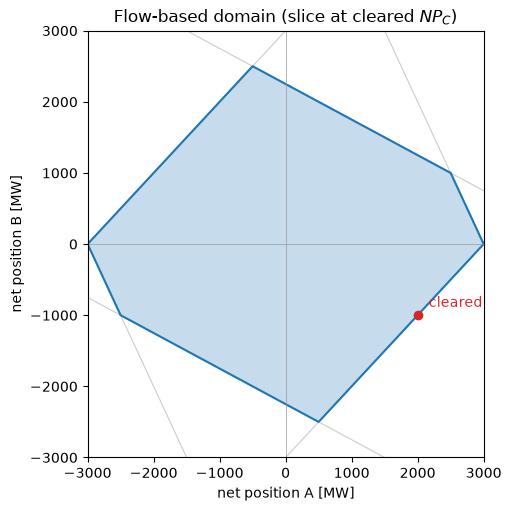

In [7]:
from scipy.optimize import linprog
from scipy.spatial import HalfspaceIntersection

# substitute NP_C = -(NP_A + NP_B): (ptdf_A - ptdf_C) NP_A + (ptdf_B - ptdf_C) NP_B <= RAM
a = (zonal_ptdf["A"] - zonal_ptdf["C"]).values
b = (zonal_ptdf["B"] - zonal_ptdf["C"]).values
rhs = ram[zonal_ptdf.index].values
halfspaces = np.column_stack([a, b, -rhs])

# Chebyshev centre as a strictly interior point for the polygon vertex enumeration
norm = np.sqrt(a**2 + b**2)
res = linprog(
    [0, 0, -1],
    A_ub=np.column_stack([a, b, norm]),
    b_ub=rhs,
    bounds=[(-3000, 3000), (-3000, 3000), (0, None)],
)
centre = res.x[:2]
poly = HalfspaceIntersection(halfspaces, centre)
verts = poly.intersections
order = np.argsort(np.arctan2(verts[:, 1] - centre[1], verts[:, 0] - centre[0]))
verts = verts[order]

np_a, np_b = n.buses_t.net_position.iloc[0][["A", "B"]]

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
ax.fill(*verts.T, alpha=0.25, color="C0")
ax.plot(*np.vstack([verts, verts[0]]).T, color="C0", lw=1.5)
grid = np.linspace(-3000, 3000, 2)
for ai, bi, ri, name in zip(a, b, rhs, zonal_ptdf.index, strict=True):
    if abs(bi) > 1e-9:
        ax.plot(grid, (ri - ai * grid) / bi, color="0.8", lw=0.8, zorder=0)
ax.scatter(np_a, np_b, color="C3", zorder=5)
ax.annotate("cleared", (np_a, np_b), textcoords="offset points", xytext=(8, 6), color="C3")
ax.set(
    xlim=(-3000, 3000),
    ylim=(-3000, 3000),
    xlabel="net position A [MW]",
    ylabel="net position B [MW]",
    title="Flow-based domain (slice at cleared $NP_C$)",
)
ax.axhline(0, color="0.6", lw=0.5)
ax.axvline(0, color="0.6", lw=0.5)

The market clears at the north-east tip where cheap A exports the most: exactly on the
`AB+` cut, the constraint whose dual we found binding.

## Coupling to neighbours: AHC and EvFB

Real zones are not islands — power reaches them over controllable HVDC corridors. The domain
expresses these through two more column families, and PyPSA handles both by letting a
`zonal_ptdf` column name an existing `Link` instead of a zone bus:

- **Advanced hybrid coupling (AHC)** — a border to a zone *outside* the domain. The external
  hub becomes a virtual zone whose net position is the interconnector flow; it joins the
  zero-sum balance and its power is priced by the external market.
- **Evolved flow-based coupling (EvFB)** — a controllable HVDC *between two domain zones*. It
  reshapes physical flow (and loads CNECs) without moving zonal energy.

Both load their CNECs through a `zonal_ptdf . Link-p` term on the existing link. To keep each
zone's net position equal to `generation - load`, the corridor's contribution to its Core-side
nodal balance is cancelled, so the flow is *not* double-counted. AHC versus EvFB is inferred
from the link's endpoints — you do not declare it.

We add a cheap external hub **X** feeding A over an AHC border, and an EvFB HVDC between A and
B, then extend the domain with one column per corridor.

In [8]:
# take the same market and add only the coupling (drop the solver model to copy)
n.model.solver_model = None
n2 = n.copy()
n2.add("Bus", "X")
n2.add("Generator", "gen_X", bus="X", p_nom=4000, marginal_cost=5.0)  # cheap neighbour
n2.add("Link", "X-A", bus0="X", bus1="A", p_nom=800, p_min_pu=-1)  # AHC border
n2.add("Link", "A-B", bus0="A", bus1="B", p_nom=400, p_min_pu=-1)  # EvFB HVDC

# extend the domain: one PTDF column per corridor link (given as input)
zonal_ptdf2 = zonal_ptdf.copy()
zonal_ptdf2["X-A"] = [0.3, -0.3, 0.2, -0.2, 0.25, -0.25]
zonal_ptdf2["A-B"] = [0.15, -0.15, -0.1, 0.1, 0.2, -0.2]
n2.add(
    "FlowBasedConstraint",
    zonal_ptdf2.index,
    zonal_ptdf=zonal_ptdf2,
    ram=ram.values,
    overwrite=True,
)

n2.optimize(assign_all_duals=True)

/tmp/ipykernel_1046667/3909014704.py:21: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n2.optimize(assign_all_duals=True)
Index(['A', 'B', 'C', 'X'], dtype='object', name='name')


Index(['X-A', 'A-B'], dtype='object', name='name')


Index(['0', '1', '2'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.03s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9 primals, 23 duals
Objective: 5.19e+04
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



('ok', 'optimal')

### Net position versus physical injection

With corridors present, the **net position** (`generation - load`, in `n.buses_t.net_position`)
and the **physical injection** (`n.buses_t.p`, which now includes the corridor flow) diverge
for the coupled zone A. The domain constrains the former; the latter is what physically flows.
The AHC virtual hub's net position is read from the link flow `n.links_t.p0`.

In [9]:
gen_load = (
    n2.generators_t.p.iloc[0].groupby(n2.generators.bus).sum().reindex(zones).fillna(0)
    - load
)
compare = pd.DataFrame(
    {
        "net position [MW]": n2.buses_t.net_position.iloc[0][zones].round(0),
        "physical injection buses_t.p [MW]": n2.buses_t.p.iloc[0][zones].round(0),
        "generation - load [MW]": gen_load.round(0),
    }
)
print("sum of zone net positions:", n2.buses_t.net_position.iloc[0][zones].sum().round(1), "MW")
print("AHC hub X net position (link X-A):", n2.links_t.p0.iloc[0]["X-A"].round(1), "MW")
print("EvFB flow A-B (net-zero, internal):", n2.links_t.p0.iloc[0]["A-B"].round(1), "MW")
compare

sum of zone net positions: -800.0 MW
AHC hub X net position (link X-A): 800.0 MW
EvFB flow A-B (net-zero, internal): -400.0 MW


,net position [MW],physical injection buses_t.p [MW],generation - load [MW]
A,1330.0,2530.0,1330.0
B,-1130.0,-1530.0,-1130.0
C,-1000.0,-1000.0,-1000.0


A now imports 800 MW of cheap power from X over the AHC border, so its net position
(`generation - load`) falls while its physical injection `buses_t.p` stays higher by exactly
the corridor inflow. The zone net positions no longer sum to zero on their own: the missing
800 MW is the AHC hub's net position, which balances the plate. The EvFB flow moves energy
between A and B internally and cancels out of the zonal balance — it only reshapes the physical
flows that load the CNECs.

**Caveat on real networks.** When the corridor column maps to an *aggregated* interconnector
(e.g. a clustered network where one link lumps several physical tie-lines), its `p_nom` and
flow no longer represent the single HVDC the domain column refers to. For a faithful EvFB or
AHC capacity, map the column to a dedicated HVDC link with the corridor's own rating.

## Summary

The `FlowBasedConstraint` component turns a published flow-based domain into a market clearing with
native zonal prices. The headline FBMC indicators are read from standard accessors:

| indicator | accessor |
| --- | --- |
| net positions | `n.buses_t.net_position` |
| zonal prices | `n.buses_t.marginal_price` |
| CNEC shadow prices | `n.flow_based_constraints_t.mu_domain` (needs `assign_all_duals=True`) |
| binding CNECs | `mu_domain != 0` |
| AHC hub net positions | `n.links_t.p0` |

Published domains can be imported directly with `n.c.flow_based_constraints.from_eraa(...)`,
`.from_jao(...)` and `.from_tso(...)`; see the
[user guide](../user-guide/components/flow-based-constraints.md).